**Cleaning Data**

In [ ]:
import pandas as pd

df = pd.read_csv('C:\\Users\\AKBAR\\Documents\\realtor-data.csv')

# Konversi kolom tanggal ke format datetime
df['prev_sold_date'] = pd.to_datetime(df['prev_sold_date'], errors='coerce')

# Mengisi nilai kosong pada kolom numerik dengan median atau mean
df['price'].fillna(df['price'].median(), inplace=True)
df['bed'].fillna(df['bed'].median(), inplace=True)
df['bath'].fillna(df['bath'].median(), inplace=True)
df['acre_lot'].fillna(df['acre_lot'].mean(), inplace=True)
df['house_size'].fillna(df['house_size'].mean(), inplace=True)

# Mengisi nilai kosong pada kolom kategorikal dengan modus 
df['brokered_by'].fillna(df['brokered_by'].mode()[0], inplace=True)
df['status'].fillna(df['status'].mode()[0], inplace=True)
df['street'].fillna(df['street'].mode()[0], inplace=True)
df['city'].fillna(df['city'].mode()[0], inplace=True)
df['state'].fillna(df['state'].mode()[0], inplace=True)
df['zip_code'].fillna(df['zip_code'].mode()[0], inplace=True)

# Menghapus baris yang masih memiliki nilai kosong
df_cleaned = df.dropna()

# Menyimpan dataframe yang telah dibersihkan ke file CSV
output_file_path = 'C:\\Users\\AKBAR\\Documents\\realtor-data-cleaned.csv'
df_cleaned.to_csv(output_file_path, index=False)

print(f"Data cleaned successfully saved to '{output_file_path}'!")


C:\Users\AKBAR\AppData\Local\Temp\ipykernel_10704\350951490.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['price'].fillna(df['price'].median(), inplace=True)
C:\Users\AKBAR\AppData\Local\Temp\ipykernel_10704\350951490.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

Data cleaned successfully saved to 'C:\Users\AKBAR\Documents\realtor-data-cleaned.csv'!


In [2]:
df_cleaned.isnull().sum()

brokered_by       0
status            0
price             0
bed               0
bath              0
acre_lot          0
street            0
city              0
state             0
zip_code          0
house_size        0
prev_sold_date    0
dtype: int64

**Visualisasi Tren**

C:\Users\AKBAR\AppData\Local\Temp\ipykernel_10704\1090721534.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['prev_sold_date'] = pd.to_datetime(df_cleaned['prev_sold_date'])
C:\Users\AKBAR\AppData\Local\Temp\ipykernel_10704\1090721534.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['year'] = df_cleaned['prev_sold_date'].dt.year


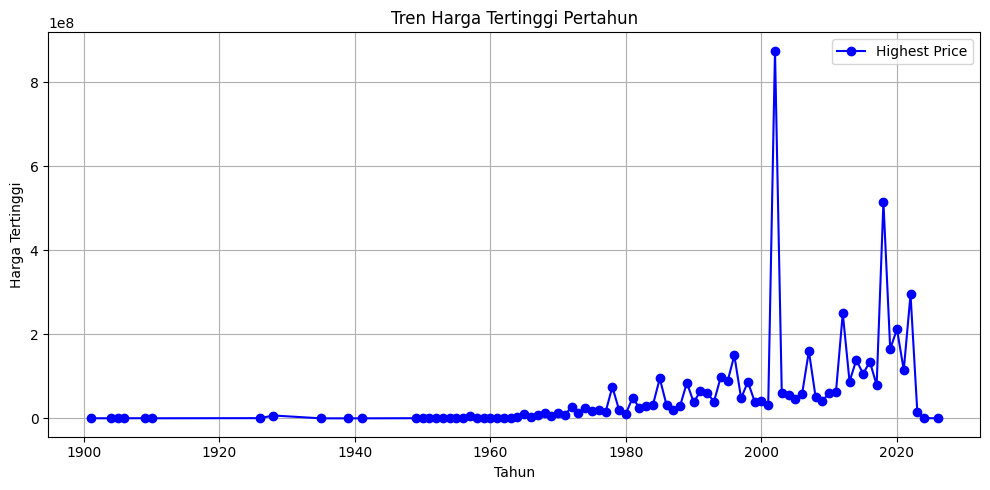

Tahun dengan Harga Tertinggi: 2002.0
Harga Tertinggi: 875000000.0


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Konversi kolom tanggal menjadi tipe datetime
df_cleaned['prev_sold_date'] = pd.to_datetime(df_cleaned['prev_sold_date'])

# Tambahkan kolom tahun
df_cleaned['year'] = df_cleaned['prev_sold_date'].dt.year

# Agregasi harga tertinggi berdasarkan tahun
yearly_max_price = df_cleaned.groupby('year')['price'].max().reset_index()

# Plot tren harga tertinggi per tahun
plt.figure(figsize=(10, 5))
plt.plot(yearly_max_price['year'], yearly_max_price['price'],
         marker='o', color='blue', label='Highest Price')
plt.title('Tren Harga Tertinggi Pertahun')
plt.xlabel('Tahun')
plt.ylabel('Harga Tertinggi')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Tampilkan tahun dengan harga tertinggi
highest_year = yearly_max_price.loc[yearly_max_price['price'].idxmax()]
print("Tahun dengan Harga Tertinggi:", highest_year['year'])
print("Harga Tertinggi:", highest_year['price'])


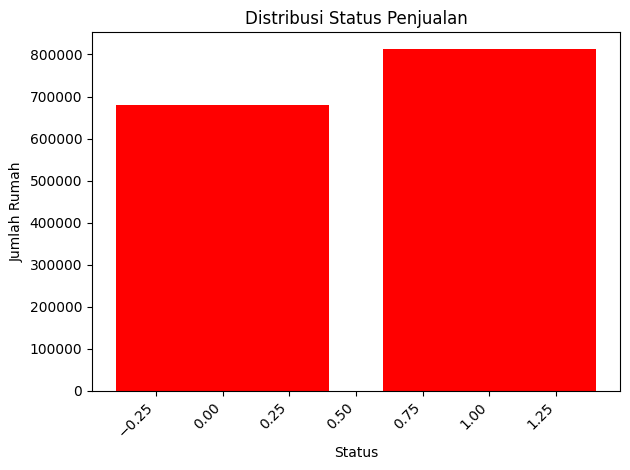

In [ ]:
import matplotlib.pyplot as plt

# Hitung jumlah penjualan berdasarkan kolom status
status_counts = df_cleaned['status'].value_counts()

# Membuat grafik bar untuk distribusi kolom status
plt.bar(status_counts.index, status_counts.values, color='red')
plt.title("Distribusi Status Penjualan")
plt.xlabel("Status")
plt.ylabel("Jumlah Rumah")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Machine Learning Model**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE  # Import SMOTE
from collections import Counter

# Step 1: Preprocessing Data
# Menentukan fitur dan target
features = ['price', 'bed', 'bath', 'acre_lot', 'house_size']
target = 'status'

# Encode target
df_cleaned[target] = df_cleaned[target].map({'for_sale': 0, 'sold': 1})

X = df_cleaned[features]
y = df_cleaned[target]

# Step 2: Oversampling using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Original class distribution:", Counter(y))
print("Resampled class distribution:", Counter(y_resampled))

# Step 3: Split the resampled data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Step 4: Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 5: Evaluate Model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

C:\Users\AKBAR\AppData\Local\Temp\ipykernel_10704\1484099037.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[target] = df_cleaned[target].map({'for_sale': 0, 'sold': 1, 'under_contract': 2})


Original class distribution: Counter({1: 812008, 0: 680076})
Resampled class distribution: Counter({0: 812008, 1: 812008})
              precision    recall  f1-score   support

           0       0.55      0.53      0.54    162071
           1       0.54      0.56      0.55    162733

    accuracy                           0.55    324804
   macro avg       0.55      0.55      0.55    324804
weighted avg       0.55      0.55      0.55    324804

Accuracy: 0.5456059654437754


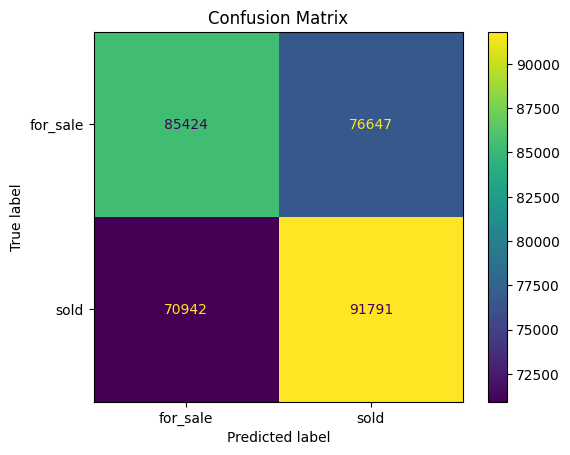

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['for_sale', 'sold']
)
plt.title('Confusion Matrix')
plt.show()


In [23]:
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

**Prediksi Fitur yang Paling berpengaruh Terhadap Status(target)**

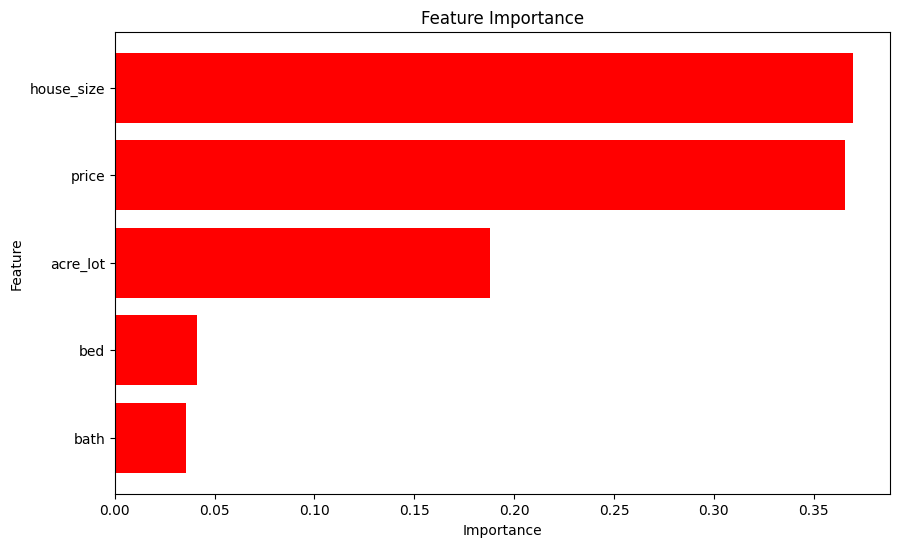

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ambil fitur penting
feature_importances = model.feature_importances_

# Tampilkan dalam DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Visualisasi fitur penting
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='red')
plt.gca().invert_yaxis() 
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


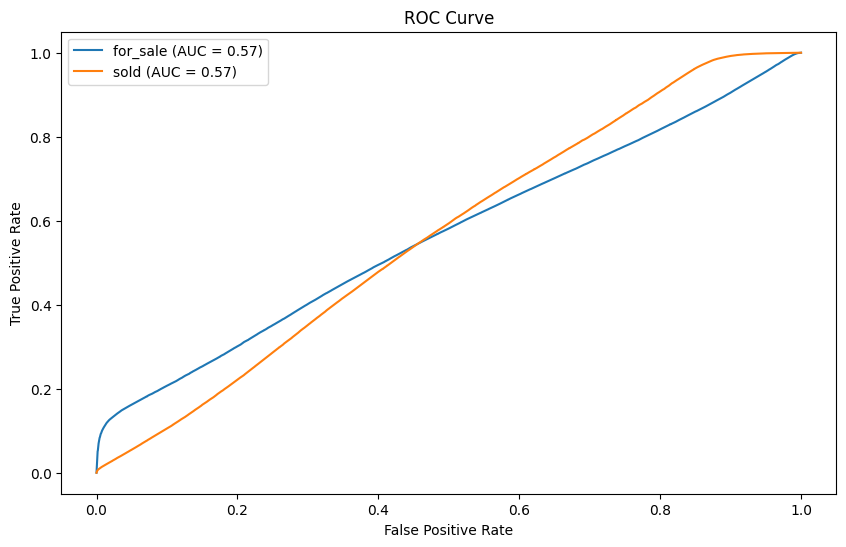

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Hitung probabilitas hanya untuk dua kelas (for sale dan sold) 
y_prob = model.predict_proba(X_test)

plt.figure(figsize=(10, 6))
for i, label in enumerate(['for_sale', 'sold']):
    fpr, tpr, _ = roc_curve(y_test == i, y_prob[:, i])
    auc = roc_auc_score(y_test == i, y_prob[:, i])
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc:.2f})')

plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()
